Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   FlightID            int64 
 1   Airline             object
 2   FlightNumber        int64 
 3   Origin              object
 4   Destination         object
 5   ScheduledDeparture  object
 6   ActualDeparture     object
 7   ScheduledArrival    object
 8   ActualArrival       object
 9   DelayMinutes        int64 
 10  DelayReason         object
 11  Cancelled           bool  
 12  Diverted            bool  
 13  AircraftType        object
 14  TailNumber          object
 15  Distance            int64 
dtypes: bool(2), int64(4), object(10)
memory usage: 190.0+ MB

First 5 rows of the dataset:
   FlightID    Airline  FlightNumber Origin Destination ScheduledDeparture  \
0         1     United          4558    ORD         MIA   2024-09-01 08:11   
1         2      Delta          8021    LAX      

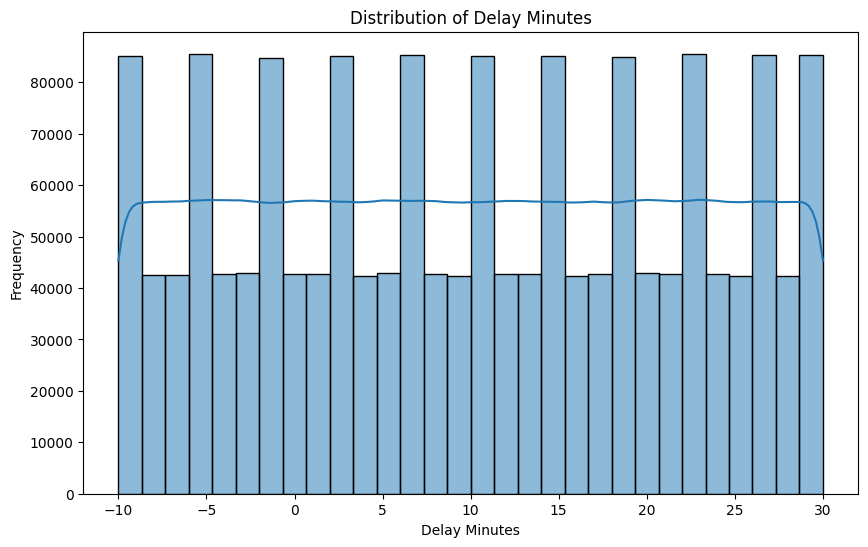

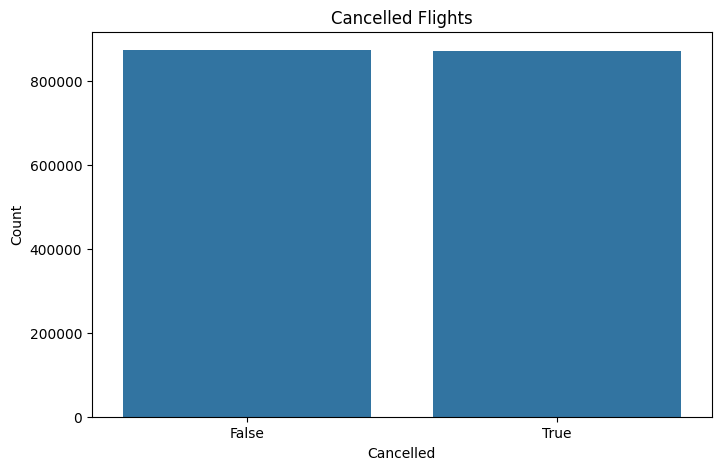

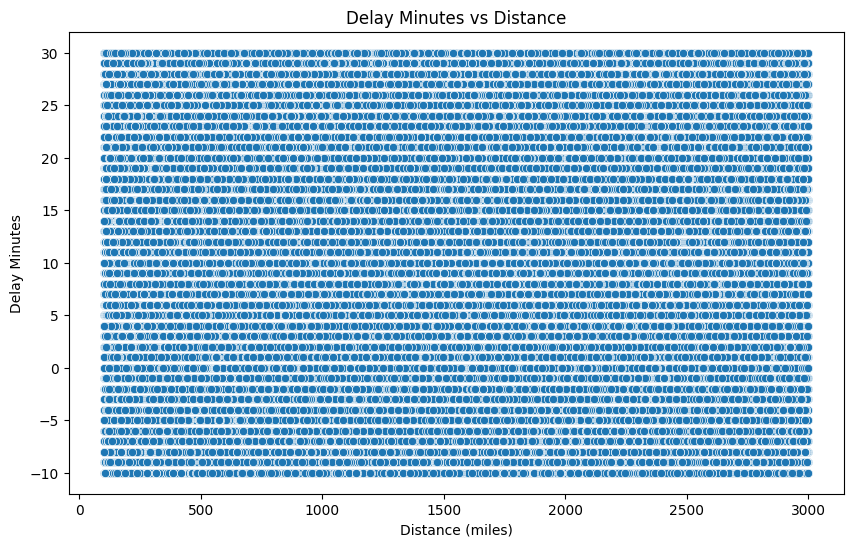

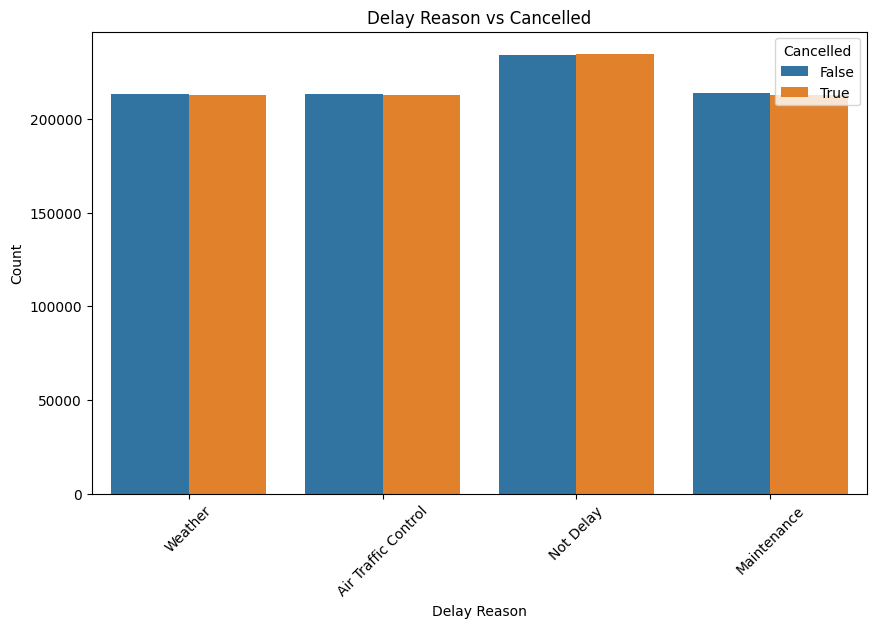

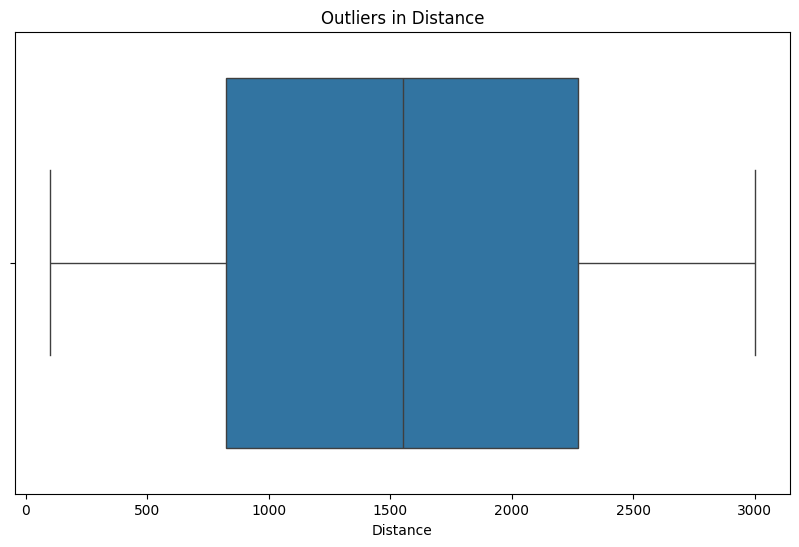

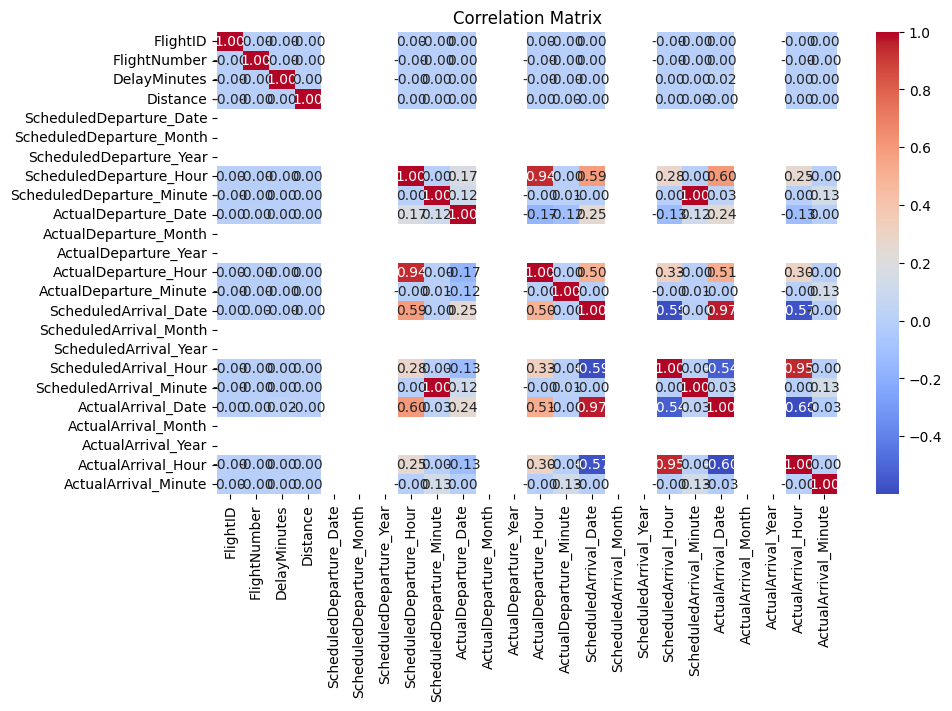


First 5 rows of cleaned data:
   FlightID    Airline  FlightNumber Origin Destination  ScheduledDeparture  \
0         1     United          4558    ORD         MIA 2024-09-01 08:11:00   
1         2      Delta          8021    LAX         MIA 2024-09-01 10:25:00   
2         3  Southwest          7520    DFW         SFO 2024-09-01 16:53:00   
3         4      Delta          2046    ORD         BOS 2024-09-01 14:44:00   
4         5      Delta          6049    LAX         SEA 2024-09-01 01:51:00   

      ActualDeparture    ScheduledArrival       ActualArrival  DelayMinutes  \
0 2024-09-01 08:30:00 2024-09-01 12:11:00 2024-09-01 12:19:00             8   
1 2024-09-01 10:41:00 2024-09-01 13:25:00 2024-09-01 13:27:00             2   
2 2024-09-01 17:05:00 2024-09-01 17:53:00 2024-09-01 18:07:00            14   
3 2024-09-01 15:04:00 2024-09-01 18:44:00 2024-09-01 18:34:00           -10   
4 2024-09-01 02:08:00 2024-09-01 05:51:00 2024-09-01 06:15:00            24   

   ... ScheduledArr

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
file_path = r"/content/New_flight_delays.csv"
df = pd.read_csv(file_path)

# Step 2: Explore the dataset
print("Dataset Info:")
df.info()

print("\nFirst 5 rows of the dataset:")
print(df.head())

# Step 3: Check for missing values
print("\nMissing values in the dataset:")
print(df.isnull().sum())

# Step 4: Handle missing values
df['DelayReason'] = df['DelayReason'].fillna('Not Delay')
df['DelayMinutes'] = df['DelayMinutes'].fillna(0)

# Step 5: Convert date/time columns to datetime
df['ScheduledDeparture'] = pd.to_datetime(df['ScheduledDeparture'], errors='coerce')
df['ActualDeparture'] = pd.to_datetime(df['ActualDeparture'], errors='coerce')
df['ScheduledArrival'] = pd.to_datetime(df['ScheduledArrival'], errors='coerce')
df['ActualArrival'] = pd.to_datetime(df['ActualArrival'], errors='coerce')

# Step 6: Extract Date, Time, Month, Hours, Minutes
# For ScheduledDeparture
df['ScheduledDeparture_Date'] = df['ScheduledDeparture'].dt.day
df['ScheduledDeparture_Month'] = df['ScheduledDeparture'].dt.month
df['ScheduledDeparture_Year'] = df['ScheduledDeparture'].dt.year
df['ScheduledDeparture_Hour'] = df['ScheduledDeparture'].dt.hour
df['ScheduledDeparture_Minute'] = df['ScheduledDeparture'].dt.minute
# For ActualDeparture
df['ActualDeparture_Date'] = df['ActualDeparture'].dt.day
df['ActualDeparture_Month'] = df['ActualDeparture'].dt.month
df['ActualDeparture_Year'] = df['ActualDeparture'].dt.year
df['ActualDeparture_Hour'] = df['ActualDeparture'].dt.hour
df['ActualDeparture_Minute'] = df['ActualDeparture'].dt.minute
# For ScheduledArrival
df['ScheduledArrival_Date'] = df['ScheduledArrival'].dt.day
df['ScheduledArrival_Month'] = df['ScheduledArrival'].dt.month
df['ScheduledArrival_Year'] = df['ScheduledArrival'].dt.year
df['ScheduledArrival_Hour'] = df['ScheduledArrival'].dt.hour
df['ScheduledArrival_Minute'] = df['ScheduledArrival'].dt.minute
# For ActualArrival
df['ActualArrival_Date'] = df['ActualArrival'].dt.day
df['ActualArrival_Month'] = df['ActualArrival'].dt.month
df['ActualArrival_Year'] = df['ActualArrival'].dt.year
df['ActualArrival_Hour'] = df['ActualArrival'].dt.hour
df['ActualArrival_Minute'] = df['ActualArrival'].dt.minute

# Step 7: Remove duplicate rows
df = df.drop_duplicates()

# Step 8: Check for outliers in DelayMinutes
df = df[df['DelayMinutes'] <= 300]

# Step 9: Convert necessary columns to appropriate data types
df['Cancelled'] = df['Cancelled'].astype(bool)
df['Diverted'] = df['Diverted'].astype(bool)
df['Distance'] = df['Distance'].astype(float)

# Step 10: Final dataset
print("\nFinal dataset info after cleaning:")
df.info()

# Step 11: Visualizing EDA

# 1. Distribution of DelayMinutes(histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['DelayMinutes'], bins=30, kde=True)
plt.title('Distribution of Delay Minutes')
plt.xlabel('Delay Minutes')
plt.ylabel('Frequency')
plt.show()

# 2. Count of Cancelled vs Not Cancelled Flights(bar plot)
plt.figure(figsize=(8, 5))
sns.countplot(x='Cancelled', data=df)
plt.title('Cancelled Flights')
plt.xlabel('Cancelled')
plt.ylabel('Count')
plt.show()

# 3. Delay Minutes vs Distance (Scatterplot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance', y='DelayMinutes', data=df)
plt.title('Delay Minutes vs Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Delay Minutes')
plt.show()

# 4. Delay Reason vs Cancelled Status (Bar Plot)
plt.figure(figsize=(10, 6))
sns.countplot(x='DelayReason', hue='Cancelled', data=df)
plt.title('Delay Reason vs Cancelled')
plt.xticks(rotation=45)
plt.xlabel('Delay Reason')
plt.ylabel('Count')
plt.show()

# 5. Outliers in Distance (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Distance', data=df)
plt.title('Outliers in Distance')
plt.show()

# 6. Correlation Matrix (Heat map)
numeric_df = df.select_dtypes(include=[np.number])  # Select only numeric columns
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Step 12: Save the cleaned dataset for future use
df.to_csv(r"/content/cleaned_flight_delays.csv", index=False)

# Step 13: Display first 5 rows of cleaned dataset
print("\nFirst 5 rows of cleaned data:")
print(df.head())

In [ ]:

# Handle Outliers
# Assuming df is your DataFrame
def handle_outliers(df):
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        # Calculate the IQR(Interquartile Range)
        IQR = Q3 - Q1

        # Calculate lower and upper bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Replace outliers with the bounds
        df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))

    return df

# Example usage:
df = pd.read_csv(r"/content/cleaned_flight_delays.csv")
df = handle_outliers(df)

# Recheck data distribution
print(df.describe())

           FlightID  FlightNumber  DelayMinutes      Distance  \
count  1.747627e+06  1.747627e+06  1.747627e+06  1.747627e+06   
mean   8.738140e+05  5.001158e+03  9.999179e+00  1.549936e+03   
std    5.044966e+05  2.885822e+03  1.183112e+01  8.368681e+02   
min    1.000000e+00  1.000000e+00 -1.000000e+01  1.000000e+02   
25%    4.369075e+05  2.503000e+03  0.000000e+00  8.250000e+02   
50%    8.738140e+05  5.002000e+03  1.000000e+01  1.551000e+03   
75%    1.310720e+06  7.499000e+03  2.000000e+01  2.274000e+03   
max    1.747627e+06  9.999000e+03  3.000000e+01  3.000000e+03   

       ScheduledDeparture_Date  ScheduledDeparture_Month  \
count                1747627.0                 1747627.0   
mean                       1.0                       9.0   
std                        0.0                       0.0   
min                        1.0                       9.0   
25%                        1.0                       9.0   
50%                        1.0                       9

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = r"/content/cleaned_flight_delays.csv"
df = pd.read_csv(file_path)

# Ensure datetime conversion (fix for datetime handling)
df['ScheduledDeparture'] = pd.to_datetime(df['ScheduledDeparture'], errors='coerce')
df['ActualDeparture'] = pd.to_datetime(df['ActualDeparture'], errors='coerce')
df['ScheduledArrival'] = pd.to_datetime(df['ScheduledArrival'], errors='coerce')
df['ActualArrival'] = pd.to_datetime(df['ActualArrival'], errors='coerce')

# Check the data types to ensure datetime conversion
print(df.dtypes)

# Outlier Handling (Capping)
def handle_outliers(df):
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        # Calculate the IQR (Interquartile Range)
        IQR = Q3 - Q1

        # Calculate lower and upper bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Replace outliers with the bounds
        df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))

    return df

# Apply outlier handling
df = handle_outliers(df)

# Create 'Route' feature by combining 'Origin' and 'Destination'
df['Route'] = df['Origin'] + '-' + df['Destination']

# Create 'Season' feature based on Month
df['Season'] = df['ScheduledDeparture_Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else ('Spring' if x in [3, 4, 5] else ('Summer' if x in [6, 7, 8] else 'Fall')))

# Create 'Day of Week' feature from 'ScheduledDeparture'
df['DayOfWeek'] = df['ScheduledDeparture'].dt.day_name()

# Categorical Encoding
# Label encoding for 'Airline' column
le = LabelEncoder()
df['Airline_encoded'] = le.fit_transform(df['Airline'])

# Aggregation Example
df['Month'] = df['ScheduledDeparture_Month']
monthly_data = df.groupby(['Month']).agg({
    'DelayMinutes': 'mean',
    'Distance': 'mean',
    'Cancelled': 'sum'
}).reset_index()


df.to_csv(r"/content/final_flight_delays_for_dashboard.csv", index=False)

print("Final Data Overview:")
print(df.head())



FlightID                              int64
Airline                              object
FlightNumber                          int64
Origin                               object
Destination                          object
ScheduledDeparture           datetime64[ns]
ActualDeparture              datetime64[ns]
ScheduledArrival             datetime64[ns]
ActualArrival                datetime64[ns]
DelayMinutes                          int64
DelayReason                          object
Cancelled                              bool
Diverted                               bool
AircraftType                         object
TailNumber                           object
Distance                            float64
ScheduledDeparture_Date               int64
ScheduledDeparture_Month              int64
ScheduledDeparture_Year               int64
ScheduledDeparture_Hour               int64
ScheduledDeparture_Minute             int64
ActualDeparture_Date                  int64
ActualDeparture_Month           